## Step 0: Mounting Google Drive and Importing Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/multimodal-xray-agent

In [ ]:
!pip install faiss-cpu crewai open_clip_torch groq -q

In [ ]:
!pip install bert-score -q

In [11]:
import os
import time
import json
import base64

import random
import numpy as np
import pandas as pd

from PIL import Image
from openai import OpenAI
from typing import Dict, List
from collections import Counter
from google.colab import userdata
from bert_score import score as bertscore
from crewai import Agent, Crew, Task, LLM, Process

from src.tools.pubmed_tool import PubmedRetrievalTool
from src.tools.vision_caption_groq import VisionCaptionTool
from src.tools.iu_retrieval_tool import IUImpressionSearchTool

In [3]:
from src.tools.vision_caption_gpt import GPT4oVisionTool

In [24]:
from src.tools.vision_caption_tool import VisionCaptionTool as VisionCaptionToolGemini

In [6]:
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

## Step 1: Creating the Evaluation Dataset

In [ ]:
csv_path = "/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/chest14.csv"

In [ ]:
df = pd.read_csv(csv_path)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  object 
 5   Patient Gender               112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
dtypes: float64(3), int64(4), object(5)
memory usage: 10.3+ MB


In [ ]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN


In [ ]:
len(df[df['Finding Labels'] == 'No Finding'])

60412

In [ ]:
# Remove "No Finding" cases
df = df[df["Finding Labels"] != "No Finding"].copy()

In [ ]:
# Create a new column that stores labels as a list
df["label_list"] = df["Finding Labels"].apply(lambda x: x.split("|"))

In [ ]:
# Add a column for label count (used later for stratified sampling)
df["label_count"] = df["label_list"].apply(len)

In [ ]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,label_list,label_count
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN,[Cardiomegaly],1
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN,"[Cardiomegaly, Emphysema]",2
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN,"[Cardiomegaly, Effusion]",2
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN,[Hernia],1
5,00000003_001.png,Hernia,1,3,074Y,F,PA,2500,2048,0.168,0.168,NaN,[Hernia],1


In [ ]:
df = df[df["View Position"].isin(["PA"])].copy()

In [ ]:
len(df)

27990

In [ ]:
print(df.columns.tolist())

['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11', 'label_list', 'label_count']


In [ ]:
# Flatten all label lists and count occurrences
all_labels = df['label_list'].explode()
label_counts = Counter(all_labels)

In [ ]:
label_counts_df = pd.DataFrame.from_dict(label_counts, orient='index', columns=['count'])
label_counts_df = label_counts_df.sort_values(by='count', ascending=False)

In [ ]:
# Display top pathologies
label_counts_df.head(15)

,count
Infiltration,9344
Effusion,6585
Atelectasis,5715
Nodule,4172
Mass,3547
Pneumothorax,3405
Pleural_Thickening,2418
Cardiomegaly,1559
Consolidation,1521
Emphysema,1499


In [ ]:
top8_labels = [
    "Infiltration", "Effusion", "Atelectasis", "Nodule",
    "Mass", "Pneumothorax", "Pleural_Thickening", "Cardiomegaly"
]

In [ ]:
# Filter samples with >= 2 conditions
df_multi = df[df['label_count'] >= 2].copy()

In [ ]:
# Keep only rows that include at least one of the top 8 pathologies
def includes_top8(labels):
    return any(label in top8_labels for label in labels)

df_multi_top8 = df_multi[df_multi['label_list'].apply(includes_top8)].reset_index(drop=True)

In [ ]:
print(f"Multi-label samples with at least one top-8 condition: {len(df_multi_top8)} rows")

Multi-label samples with at least one top-8 condition: 10074 rows


In [ ]:
df_multi_top8[['Image Index', 'label_list']].head()

,Image Index,label_list
0,00000001_001.png,"[Cardiomegaly, Emphysema]"
1,00000001_002.png,"[Cardiomegaly, Effusion]"
2,00000003_003.png,"[Hernia, Infiltration]"
3,00000005_007.png,"[Effusion, Infiltration]"
4,00000012_000.png,"[Effusion, Mass]"


In [ ]:
random.seed(42)
final_samples = []

In [ ]:
# Track which images we've already included
used_indices = set()

In [ ]:
# Try to get ~4 samples per pathology
samples_per_class = 4

In [ ]:
for label in top8_labels:
    # Subset rows that include this label and haven't already been chosen
    subset = df_multi_top8[
        df_multi_top8['label_list'].apply(lambda x: label in x)
        & (~df_multi_top8['Image Index'].isin(used_indices))
    ]

    # Sample up to N rows
    sampled = subset.sample(
        n=min(samples_per_class, len(subset)),
        random_state=42
    )

    # Add to final list and update used indices
    final_samples.append(sampled)
    used_indices.update(sampled['Image Index'].tolist())

In [ ]:
# Concatenate all samples into final DataFrame
df_eval = pd.concat(final_samples).drop_duplicates(subset='Image Index').reset_index(drop=True)

In [ ]:
# Final shape (should be around 30)
print(f"Final evaluation set size: {len(df_eval)}")
df_eval[['Image Index', 'label_list']]

Final evaluation set size: 32


,Image Index,label_list
0,00004858_011.png,"[Atelectasis, Infiltration, Pleural_Thickening]"
1,00006044_005.png,"[Infiltration, Pleural_Thickening]"
2,00028540_000.png,"[Atelectasis, Infiltration]"
3,00013194_003.png,"[Atelectasis, Infiltration]"
4,00001235_000.png,"[Effusion, Pleural_Thickening]"
5,00013000_000.png,"[Effusion, Fibrosis]"
6,00004526_006.png,"[Cardiomegaly, Effusion, Infiltration]"
7,00011104_003.png,"[Atelectasis, Effusion]"
8,00014687_003.png,"[Atelectasis, Consolidation, Infiltration, Ple..."
9,00019766_022.png,"[Atelectasis, Infiltration]"


In [ ]:
df_eval.columns

Index(['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID',
       'Patient Age', 'Patient Gender', 'View Position', 'OriginalImage[Width',
       'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11',
       'label_list', 'label_count'],
      dtype='object')

In [ ]:
save_path = "/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/chest14_eval.csv"

In [ ]:
# Save only the required columns
df_eval[["Image Index", "label_list"]].to_csv(save_path, index=False)

# Step 2a: Generating Reports Using Multi-Agent System (Llama 4 Maverick)

Temperature is set to a low value for tasks (drafting and critiquing) for which low stochasticity is preferred. Experimenting with top_k and top_p values can also be done, but here, they are set to the default values.

In [159]:
# Initialize LLMs and tools
llm = LLM(model="groq/meta-llama/llama-4-scout-17b-16e-instruct", temperature=0.2)
llm2 = LLM(model="groq/llama-3.3-70b-versatile", temperature=0.1)
llm3 = LLM(model="groq/llama3-70b-8192")
llm4 = LLM(model="groq/gemma2-9b-it")
llm5 = LLM(model="groq/deepseek-r1-distill-llama-70b", temperature=0.3)
llm6 = LLM(model="groq/meta-llama/llama-4-maverick-17b-128e-instruct", temperature=0.2)
llm7 = LLM(model="groq/compound-beta")
llm8 = LLM(model="groq/moonshotai/kimi-k2-instruct")

In [160]:
caption_tool = VisionCaptionTool(metadata={"GROQ_API_KEY": os.getenv("GROQ_API_KEY")})

In [161]:
pubmed_tool = PubmedRetrievalTool(data_dir="/content/drive/MyDrive/multimodal-xray-agent/data/pubmed_filtered", top_k=3)
pubmed_tool.name = "pubmed_retrieval_tool"

In [162]:
iu_tool = IUImpressionSearchTool(metadata={
    "VEC_PATH": "/content/drive/MyDrive/multimodal-xray-agent/data/iu_xray/iu_vecs.npy",
    "IMPR_PATH": "/content/drive/MyDrive/multimodal-xray-agent/data/iu_xray/iu_impr.jsonl",
    "MODEL_ID": "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
})

In [163]:
# Initialize agents
vision_agent = Agent(
    role="Radiology Captioning Agent",
    goal="Use the vision_caption_tool and return back the exact output. DO NOT add, interpret, or speculate beyond what the vision_caption_tool outputs",
    backstory="A world-class expert radiologist AI specialized in chest X-ray interpretation",
    tools=[caption_tool],
    allow_delegation=False,
    verbose=True,
    llm=llm
)

In [164]:
pubmed_agent = Agent(
    role="Biomedical Literature Retriever specialzing in retrieving the most relevant PubMed abstracts for a given chest X-ray impression",
    goal=(
        '''
        Perform a SINGLE search for the top 3 most relevant PubMed abstracts
        based on a given medical caption using the pubmed_tool.
        '''
    ),
    backstory=(
        '''
        You are an AI literature assistant. Your sole purpose is to take a
        text caption, use your tool exactly once to find relevant citations,
        and present the formatted output directly as your final answer.
        '''
    ),
    tools=[pubmed_tool],
    verbose=False,
    llm=llm8
)

In [165]:
iu_agent = Agent(
    role="Retrieval Agent specializing in retrieving the most semantically-similar IU chest X-ray impression",
    goal="Find and return the most semantically similar impression from the IU-Xray dataset based on a given chest X-ray image",
    backstory=(
        '''
        You're a biomedical assistant trained on the IU-Xray dataset.
        Your job is to retrieve the closest stylistic and semantic match to the current case,
        helping the system maintain professional and realistic radiology language.
        You do not generate new content — you only retrieve.
        '''
    ),
    tools=[iu_tool],
    verbose=False,
    llm=llm4
)

In [166]:
draft_agent = Agent(
    role="Senior thoracic radiologist with expertise in drafting X-ray reports by synthesizing information from various sources",
    goal=(
        '''
        Write a clinically accurate draft radiology report for a given chest X-ray,
        using the AI-generated visual caption, the the most similar IU X-ray impression, and the top PubMed evidence.
        '''
    ),
    backstory=(
        '''
        You have 20+ years of experience drafting high-quality chest X-ray reports.
        Your strength lies in fusing image-grounded observations with medically accurate language and literature-backed phrasing.
        You prioritize clarity, medical accuracy, and correct radiological terminology over verbosity.
        You hedge uncertain findings and avoid speculative or unsupported claims.
        '''
    ),
    verbose=True,
    llm=llm5
)

In [167]:
critic_agent = Agent(
    role= "Senior thoracic radiologist specializing in auditing chest X-ray reports",
    goal=(
        "Ensure that the radiology report is concise, medically accurate, and free from hallucinations or unsupported conclusions"
    ),
    backstory=(
        '''
        You have 20+ years of experience reviewing and auditing chest X-ray reports.
        Your goal is to ensure clinical realism, eliminate hallucinations, and unsupported language, resulting in a concise and professional clinical report.
        '''
    ),
    verbose=True,
    llm=llm,
)

In [168]:
def create_tasks(image_path):
    caption_task = Task(
        description=f"Analyze the chest X-ray at '{image_path}' and return the exact output from the vision_caption_tool",
        expected_output="The VERBATIM output of the vision_caption_tool",
        agent=vision_agent
    )

    pubmed_task = Task(
        description=(
            '''
            From the vision agent's report, extract ONLY the key POSITIVE finding(s)
            from the IMPRESSION section (ignore negations or normal findings).
            Use THOSE finding(s) as the input query to the `pubmed_tool`.
            Return the top 2 most relevant PubMed citations with pmid, similarity score, title, and abstract,
            along with the finding(s) that you used as an input for the 'pubmed_tool'.
            '''
        ),
        expected_output="List of 2 relevant PubMed citations with pmid, similarity score, title, and abstract, along with the finding(s) used as input",
        agent=pubmed_agent,
        context=[caption_task]
    )

    iu_task = Task(
        description=(
            f'''
            Use the iu_tool to find the most similar impression
            in the IU-Xray dataset based on the X-ray image at '{image_path}'
            Return the image UUID and the impression text of the closest match.
            '''
        ),
        expected_output="UUID and impression of the most semantically similar IU-Xray case.",
        agent=iu_agent
    )

    draft_task = Task(
        description=(
            '''
            Your task is to write a two-part radiology report based on a chest X-ray image.

            Use the AI-generated visual caption [①] as your PRIMARY source of findings.
            You may also incorporate as SECONDARY sources:
            - Language or structure from the closest IU-Xray impression [②], and
            - Medically relevant phrasing or terminology from PubMed abstracts [③].

            However:
            - NEVER contradict the visual caption.
            - NEVER introduce information not clearly supported by one of the three sources.
            - DO NOT speculate or offer clinical context not evident the caption.
            - If findings are ambiguous or limited, hedge appropriately.

            Tag each sentence using [①], [②], or [③] to indicate which source supports it.
            This will help a critic agent verify your reasoning.

            Your report must have two sections:

            FINDINGS:
            - Objective description of radiographic features [from ①]
            - Use [②] or [③] ONLY for language improvements or secondary detail

            IMPRESSION:
            - Concise summary of likely clinical implications based on the findings
            - You may re-use validated phrases from [②] or [③] ONLY if necessary, but DO NOT overreach
            '''
        ),
        expected_output=(
            '''
            A two-part radiology report:\n\n
            FINDINGS:
            IMPRESSION:
            '''
        ),
        agent=draft_agent,
        context=[caption_task, iu_task, pubmed_task]
    )

    critic_task = Task(
        description=(
            '''
            Your task is to review and refine the draft radiology report (only the FINDINGS and IMPRESSIONS sections) for clinical accuracy, realism, and formatting.

            You MUST:
            - Validate every sentence against its source tag: [①] = Caption, [②] = IU report, [③] = PubMed abstract
            - Remove any statement not clearly supported by the visual caption
            - Remove unsupported speculation, exaggerations, or redundant hedging
            - Maintain standard MIMIC-CXR formatting: terse, focused, professional

            You MUST NOT:
            - Invent new findings or reword unsupported conclusions
            - Add clinical context not present in the visual or evidence inputs

            You MAY:
            - Improve phrasing for clarity or brevity
            - Remove footnote tags in your final output

            Output ONLY the final cleaned report. Keep section headers intact.
            '''
        ),
        expected_output=(
            '''
            A cleaned two-part radiology report:

            FINDINGS:
            [Final reviewed sentences]

            IMPRESSION:
            [Final reviewed summary]

            Do NOT include source tags. Do NOT include any commentary or explanation — only the final report.
            '''
        ),
        agent=critic_agent,
        context=[caption_task, iu_task, draft_task],
        markdown=True
    )

    return [caption_task, pubmed_task, iu_task, draft_task, critic_task]

In [169]:
def process_image(image_path):
    try:
        tasks = create_tasks(image_path)
        crew = Crew(
            agents=[vision_agent, pubmed_agent, iu_agent, draft_agent, critic_agent],
            tasks=tasks,
            retries=0,
            process=Process.sequential
        )
        result = crew.kickoff()

        # Extract only the final critic output (clean FINDINGS + IMPRESSION)
        final_output = str(result).strip()

        # If result contains multiple agent outputs, extract just the last one
        if "Task output:" in final_output:
            # Split by task outputs and take the last one (critic agent)
            task_outputs = final_output.split("Task output:")
            final_output = task_outputs[-1].strip()

        return final_output
    except Exception as e:
        return f"ERROR: {str(e)}"

In [170]:
# Main evaluation loop
images_dir = "/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/stanfordaimi_images"
output_file = "/content/drive/MyDrive/multimodal-xray-agent/crewai_evaluation_results.json"

In [171]:
image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(('.png'))])
results = []

In [172]:
for i, image_file in enumerate(image_files):
    print(f"Processing {i+1}/{len(image_files)}: {image_file}")
    image_path = os.path.join(images_dir, image_file)
    report = process_image(image_path)

    results.append({
        "image_index": image_file,
        "generated_report": report
    })

Processing 1/15: 01.png


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Radiology Captioning Agent                                                                              │
│                                                                                                                 │
│  Task: Analyze the chest X-ray at                                                                               │
│  '/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/stanfordaimi_images/01.png' and return the    │
│  exact output from the vision_caption_tool                                                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🔧 Agent Tool Execution ────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Radiology Captioning Agent                                                                              │
│                                                                                                                 │
│  Thought: Thought: I need to use the vision_caption_tool to analyze the chest X-ray image at the specified      │
│  path and return the exact output.                                                                              │
│                                                                                                                 │
│  Using Tool: vision_caption_tool                                                                                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Input ───────────────────────────────────────────────────╮
│                                                                                                                 │
│  "{\"image_path\": \"/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/stanfordaimi_images/01.pn  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Output ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  FINDINGS:                                                                                                      │
│  The airway appears patent, and the mediastinum is widened, which could be due to the supine positioning or     │
│  potentially due to other causes such as mediastinal pathology. The bones and soft tissues show no acute        │
│  fractures or significant abnormalities. The cardiac silhouette is enlarged, but given the AP projection, this  │
│  should be interpreted with caution as it may be exaggerated due to the projection. The diaphragm is obscured   │
│  by the cardiac and possible pleural opacities. The lung fields show bilateral opacities, more pronounced at    │
│  the lower zones, which could be indicative of pulmonary edema, infection, or other infiltrative processes.     │
│  There are no clear signs of chronic lung disease such as emphysema or fibrosis visible on this image. The      │
│  pleura appears to have bilateral effusions or significant opacities obscuring the costophrenic angles. There   │
│  are ECG leads visible on the chest, indicating monitoring. The overall image quality is limited by the         │
│  semi-erect, portable technique, which can affect the assessment of certain findings.                           │
│                                                                                                                 │
│  IMPRESSION:                                                                                                    │
│  The most significant finding is the bilateral opacities in the lung fields, which are probable pulmonary       │
│  edema or infection, given the clinical context of a portable, semi-erect chest X-ray. The cardiac silhouette   │
│  enlargement is possible cardiomegaly, but this is less certain due to the AP projection. Bilateral pleural     │
│  effusions are also possible, contributing to the observed opacities. The presence of ECG leads suggests that   │
│  the patient is being monitored, supporting the likelihood of a significant cardiac or respiratory condition.   │
│  Further clinical correlation and potentially additional imaging are recommended to confirm these findings.     │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

Embedding with SPECTER2:   0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
Embedding with SPECTER2: 100%|██████████| 1/1 [00:00<00:00,  5.55it/s]


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior thoracic radiologist with expertise in drafting X-ray reports by synthesizing information from   │
│  various sources                                                                                                │
│                                                                                                                 │
│  Task:                                                                                                          │
│              Your task is to write a two-part radiology report based on a chest X-ray image.                    │
│                                                                                                                 │
│              Use the AI-generated visual caption [①] as your PRIMARY source of findings.                        │
│              You may also incorporate as SECONDARY sources:                                                     │
│              - Language or structure from the closest IU-Xray impression [②], and                               │
│              - Medically relevant phrasing or terminology from PubMed abstracts [③].                            │
│                                                                                                                 │
│              However:                                                                                           │
│              - NEVER contradict the visual caption.                                                             │
│              - NEVER introduce information not clearly supported by one of the three sources.                   │
│              - DO NOT speculate or offer clinical context not evident the caption.                              │
│              - If findings are ambiguous or limited, hedge appropriately.                                       │
│                                                                                                                 │
│              Tag each sentence using [①], [②], or [③] to indicate which source supports it.                     │
│              This will help a critic agent verify your reasoning.                                               │
│                                                                                                                 │
│              Your report must have two sections:                                                                │
│                                                                                                                 │
│              FINDINGS:                                                                                          │
│              - Objective description of radiographic features [from ①]                                          │
│              - Use [②] or [③] ONLY for language improvements or secondary detail                                │
│                                                                                                                 │
│              IMPRESSION:                                                                                        │
│              - Concise summary of likely clinical implications based on the findings                            │
│              - You may re-use validated phrases from [②] or [③] ONLY if necessary, but DO NOT overreach         │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior thoracic radiologist with expertise in drafting X-ray reports by synthesizing information from   │
│  various sources                                                                                                │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  **                                                                                                             │
│                                                                                                                 │
│  **FINDINGS:**                                                                                                  │
│  - The chest X-ray is a portable, semi-erect AP film [①].                                                       │
│  - The mediastinum is widened, which may be due in part to the AP projection [①].                               │
│  - The cardiac silhouette appears enlarged, but this may be projectional [①].                                   │
│  - The bones and soft tissues show no acute abnormalities [①].                                                  │
│  - The diaphragm is obscured by bilateral lower lobe opacities [①].                                             │
│  - The lung fields demonstrate diffuse, bilateral interstitial opacities, more pronounced at the bases, with    │
│  some areas of confluence suggesting consolidation or atelectasis [①].                                          │
│  - There are no signs of pneumothorax [①].                                                                      │
│  - The pleura is not clearly visible due to the opacities [①].                                                  │
│  - Devices/foreign objects include an endotracheal tube, a central venous catheter, and ECG leads [①].          │
│  - There are no obvious signs of chronic lung disease such as emphysema or fibrosis visible on this image [①].  │
│                                                                                                                 │
│  **IMPRESSION:**                                                                                                │
│  - The most significant finding is the presence of bilateral lower lobe opacities, likely representing          │
│  consolidation or atelectasis, which is probable pulmonary edema or pneumonia [①].                              │
│  - The widened mediastinum and enlarged cardiac silhouette are possible signs of cardiomegaly or other cardiac  │
│  pathology, but these findings are less certain due to the AP projection [①].                                   │
│  - The presence of an endotracheal tube and central venous catheter suggests that the patient is critically     │
│  ill [①].                                                                                                       │
│  - Further clinical correlation is necessary to determine the underlying cause of the lung opacities [①].       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior thoracic radiologist specializing in auditing chest X-ray reports                                │
│                                                                                                                 │
│  Task:                                                                                                          │
│              Your task is to review and refine the draft radiology report (only the FINDINGS and IMPRESSIONS    │
│  sections) for clinical accuracy, realism, and formatting.                                                      │
│                                                                                                                 │
│              You MUST:                                                                                          │
│              - Validate every sentence against its source tag: [①] = Caption, [②] = IU report, [③] = PubMed     │
│  abstract                                                                                                       │
│              - Remove any statement not clearly supported by the visual caption                                 │
│              - Remove unsupported speculation, exaggerations, or redundant hedging                              │
│              - Maintain standard MIMIC-CXR formatting: terse, focused, professional                             │
│                                                                                                                 │
│              You MUST NOT:                                                                                      │
│              - Invent new findings or reword unsupported conclusions                                            │
│              - Add clinical context not present in the visual or evidence inputs                                │
│                                                                                                                 │
│              You MAY:                                                                                           │
│              - Improve phrasing for clarity or brevity                                                          │
│              - Remove footnote tags in your final output                                                        │
│                                                                                                                 │
│              Output ONLY the final cleaned report. Keep section headers intact.                                 │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior thoracic radiologist specializing in auditing chest X-ray reports                                │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Thought: I now can give a great answer                                                                         │
│                                                                                                                 │
│  # FINDINGS:                                                                                                    │
│  - The chest X-ray is a portable, semi-erect AP film.                                                           │
│  - The mediastinum is widened, which may be due in part to the AP projection.                                   │
│  - The cardiac silhouette appears enlarged, but this may be projectional.                                       │
│  - The bones and soft tissues show no acute abnormalities.                                                      │
│  - The diaphragm is obscured by bilateral lower lobe opacities.                                                 │
│  - The lung fields demonstrate diffuse, bilateral interstitial opacities, more pronounced at the bases, with    │
│  some areas of confluence suggesting consolidation or atelectasis.                                              │
│  - There are no signs of pneumothorax.                                                                          │
│  - The pleura is not clearly visible due to the opacities.                                                      │
│  - Devices/foreign objects include an endotracheal tube, a central venous catheter, and ECG leads.              │
│                                                                                                                 │
│  # IMPRESSION:                                                                                                  │
│  - The most significant finding is the presence of bilateral lower lobe opacities, likely representing          │
│  consolidation or atelectasis.                                                                                  │
│  - The widened mediastinum and enlarged cardiac silhouette are possible signs of cardiomegaly or other cardiac  │
│  pathology, but these findings are less certain due to the AP projection.                                       │
│  - The presence of an endotracheal tube and central venous catheter suggests that the patient is critically     │
│  ill.                                                                                                           │
│  - Further clinical correlation is necessary to determine the underlying cause of the lung opacities.           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [173]:
# Save results for LLM judge comparison
with open(output_file, 'w') as f:
    json.dump(results, f, indent=2)

# Step 2b: Generating Reports Using Multi-Agent System (Gemini)

We now change the LLM for the vision agent from Llama 4 Maverick to Gemini 2.5 Flash (a SOTA model for multimodel tasks). Google allows free API calls to its Gemini models, which is a great plus. If the rate limit is reached, we can switch to an older model (2.0 Flash). However, for the purposes of our evaluation, this should not be necessary.

In [9]:
caption_tool = VisionCaptionToolGemini(metadata={"GEMINI_API_KEY": os.getenv("GEMINI_API_KEY")})

In [20]:
vision_agent = Agent(
    role="Radiology Captioning Agent",
    goal="Use the vision_caption_tool and return back the exact output. DO NOT add, interpret, or speculate beyond what the vision_caption_tool outputs",
    backstory="A world-class expert radiologist AI specialized in chest X-ray interpretation",
    tools=[caption_tool],
    allow_delegation=False,
    verbose=True,
    llm=llm
)

In [23]:
images_dir = "/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/stanfordaimi_images"
output_file = "/content/drive/MyDrive/multimodal-xray-agent/crewai_evaluation_gemini.json"

In [24]:
image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(('.png'))])
results = []

In [25]:
for i, image_file in enumerate(image_files):
    print(f"Processing {i+1}/{len(image_files)}: {image_file}")
    image_path = os.path.join(images_dir, image_file)
    report = process_image(image_path)

    results.append({
        "image_index": image_file,
        "generated_report": report
    })

Processing 1/15: 01.png


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Radiology Captioning Agent                                                                              │
│                                                                                                                 │
│  Task: Analyze the chest X-ray at                                                                               │
│  '/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/stanfordaimi_images/01.png' and return the    │
│  exact output from the vision_caption_tool                                                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🔧 Agent Tool Execution ────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Radiology Captioning Agent                                                                              │
│                                                                                                                 │
│  Thought: Thought: I need to use the vision_caption_tool to analyze the chest X-ray image at the given path     │
│  and return the exact output.                                                                                   │
│                                                                                                                 │
│  Using Tool: vision_caption_tool                                                                                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Input ───────────────────────────────────────────────────╮
│                                                                                                                 │
│  "{\"image_path\": \"/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/stanfordaimi_images/01.pn  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Output ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  **FINDINGS:**                                                                                                  │
│                                                                                                                 │
│  The study is a portable, semi-erect frontal chest radiograph. Inspiration is somewhat limited, which is        │
│  common for this technique. The patient is well-centered.                                                       │
│                                                                                                                 │
│  The trachea is midline. The mediastinal contours are within normal limits for the projection, though the       │
│  cardiac silhouette is enlarged and globular. Given the portable AP projection, mild to moderate cardiomegaly   │
│  is probable. Pulmonary vascularity appears prominent, consistent with pulmonary venous congestion.             │
│                                                                                                                 │
│  The lung fields demonstrate diffuse, bilateral patchy opacities, predominantly in the mid and lower lung       │
│  zones. These opacities have a mixed reticular and ground-glass appearance, with some areas of confluent        │
│  consolidation, particularly in the lower lobes. Peribronchial cuffing and subtle septal lines (Kerley B        │
│  lines) are also noted bilaterally. There are no definite signs of chronic lung disease such as emphysema or    │
│  diffuse interstitial fibrosis.                                                                                 │
│                                                                                                                 │
│  The right hemidiaphragm is visible, and the right costophrenic angle is blunted, consistent with a small       │
│  pleural effusion. The left hemidiaphragm and costophrenic angle are obscured by overlying opacities,           │
│  precluding full assessment of the left pleural space. No definite pneumothorax is identified.                  │
│                                                                                                                 │
│  The visualized osseous structures and soft tissues are unremarkable for acute findings. ECG leads are present  │
│  on the chest wall. A central venous catheter is noted with its tip projecting over the superior vena           │
│  cava/right atrial junction.                                                                                    │
│                                                                                                                 │
│  **IMPRESSION:**                                                                                                │
│                                                                                                                 │
│  1.  Diffuse bilateral pulmonary opacities, prominent pulmonary vascularity, and septal lines, highly           │
│  suggestive of **pulmonary edema/congestive heart failure**.                                                    │
│  2.  Probable cardiomegaly, contributing to the findings of pulmonary congestion.                               │
│  3.  Small right pleural effusion. Left pleural effusion cannot be excluded due to obscuration.                 │
│  4.  No definite pneumothorax.                                                                                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

Embedding with SPECTER2:   0%|          | 0/1 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `BertSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)
Embedding with SPECTER2: 100%|██████████| 1/1 [00:00<00:00,  6.00it/s]


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior thoracic radiologist with expertise in drafting X-ray reports by synthesizing information from   │
│  various sources                                                                                                │
│                                                                                                                 │
│  Task:                                                                                                          │
│              Your task is to write a two-part radiology report based on a chest X-ray image.                    │
│                                                                                                                 │
│              Use the AI-generated visual caption [①] as your PRIMARY source of findings.                        │
│              You may also incorporate as SECONDARY sources:                                                     │
│              - Language or structure from the closest IU-Xray impression [②], and                               │
│              - Medically relevant phrasing or terminology from PubMed abstracts [③].                            │
│                                                                                                                 │
│              However:                                                                                           │
│              - NEVER contradict the visual caption.                                                             │
│              - NEVER introduce information not clearly supported by one of the three sources.                   │
│              - DO NOT speculate or offer clinical context not evident the caption.                              │
│              - If findings are ambiguous or limited, hedge appropriately.                                       │
│                                                                                                                 │
│              Tag each sentence using [①], [②], or [③] to indicate which source supports it.                     │
│              This will help a critic agent verify your reasoning.                                               │
│                                                                                                                 │
│              Your report must have two sections:                                                                │
│                                                                                                                 │
│              FINDINGS:                                                                                          │
│              - Objective description of radiographic features [from ①]                                          │
│              - Use [②] or [③] ONLY for language improvements or secondary detail                                │
│                                                                                                                 │
│              IMPRESSION:                                                                                        │
│              - Concise summary of likely clinical implications based on the findings                            │
│              - You may re-use validated phrases from [②] or [③] ONLY if necessary, but DO NOT overreach         │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior thoracic radiologist with expertise in drafting X-ray reports by synthesizing information from   │
│  various sources                                                                                                │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  <think>                                                                                                        │
│  Okay, so I need to draft a radiology report based on the given chest X-ray findings. Let me start by           │
│  understanding the sources I have. The primary source is the AI-generated visual caption, which provides        │
│  detailed findings. I also have an IU X-ray impression and some PubMed abstracts to support my language and     │
│  terminology.                                                                                                   │
│                                                                                                                 │
│  First, I'll look at the findings section. The X-ray is a portable, semi-erect AP view, which means the         │
│  patient might not have been able to stand or take a deep breath. The inspiration is suboptimal, so that could  │
│  make the heart look bigger than it is and the lung markings more crowded. I need to note that.                 │
│                                                                                                                 │
│  The cardiac silhouette is markedly enlarged, which points to severe cardiomegaly. The mediastinum is widened   │
│  because of the big heart. I should mention that clearly.                                                       │
│                                                                                                                 │
│  Looking at the lungs, there are diffuse opacities in both perihilar and lower zones. These are bilateral and   │
│  ill-defined, which suggests interstitial and alveolar edema. The pulmonary vascular markings are indistinct,   │
│  which is another sign of fluid overload. The left hemidiaphragm and cardiac border are obscured, which is the  │
│  silhouette sign, indicating something is pressing against them, likely the opacities.                          │
│                                                                                                                 │
│  There are bilateral pleural effusions, more on the left, which is consistent with heart failure. The right     │
│  diaphragm is partially obscured by some opacity, maybe from the edema or effusion.                             │
│                                                                                                                 │
│  I also see a central venous catheter in the right internal jugular vein, and its tip is in the correct         │
│  position. There are surgical clips and wires on the left chest, indicating prior cardiac surgery, and a        │
│  pacing wire over the left ventricle. No fractures or bone issues are noted.                                    │
│                                                                                                                 │
│  Now, for the impression section. The main issue is severe cardiomegaly with signs of acute decompensated       │
│  heart failure. The pulmonary edema and pleural effusions support this. I should mention the prior surgery and  │
│  the correctly placed catheter. Also, I'll recommend clinical correlation for symptoms and management.          │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior thoracic radiologist specializing in auditing chest X-ray reports                                │
│                                                                                                                 │
│  Task:                                                                                                          │
│              Your task is to review and refine the draft radiology report (only the FINDINGS and IMPRESSIONS    │
│  sections) for clinical accuracy, realism, and formatting.                                                      │
│                                                                                                                 │
│              You MUST:                                                                                          │
│              - Validate every sentence against its source tag: [①] = Caption, [②] = IU report, [③] = PubMed     │
│  abstract                                                                                                       │
│              - Remove any statement not clearly supported by the visual caption                                 │
│              - Remove unsupported speculation, exaggerations, or redundant hedging                              │
│              - Maintain standard MIMIC-CXR formatting: terse, focused, professional                             │
│                                                                                                                 │
│              You MUST NOT:                                                                                      │
│              - Invent new findings or reword unsupported conclusions                                            │
│              - Add clinical context not present in the visual or evidence inputs                                │
│                                                                                                                 │
│              You MAY:                                                                                           │
│              - Improve phrasing for clarity or brevity                                                          │
│              - Remove footnote tags in your final output                                                        │
│                                                                                                                 │
│              Output ONLY the final cleaned report. Keep section headers intact.                                 │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior thoracic radiologist specializing in auditing chest X-ray reports                                │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  # FINDINGS:                                                                                                    │
│  The study is a portable, semi-erect, anteroposterior chest radiograph with suboptimal inspiration,             │
│  contributing to apparent cardiomegaly and crowded lung markings. The cardiac silhouette is markedly enlarged,  │
│  consistent with severe cardiomegaly, and the mediastinal contours are widened due to the enlarged heart.       │
│  The lung fields show diffuse, bilateral, ill-defined perihilar and lower lung zone opacities, consistent with  │
│  interstitial and alveolar edema, along with indistinct pulmonary vascular markings. The left hemidiaphragm     │
│  and left cardiac border are partially obscured, indicating a silhouette sign. Bilateral pleural effusions are  │
│  present, more pronounced on the left, blunting the costophrenic angles. The right hemidiaphragm is partially   │
│  obscured by overlying opacity.                                                                                 │
│  A right internal jugular central venous catheter is correctly positioned at the superior vena cava/right       │
│  atrial junction. Surgical clips and wires are noted in the left chest wall, consistent with prior cardiac      │
│  surgery, and a pacing wire is seen over the left ventricle. No acute osseous abnormalities are identified.     │
│                                                                                                                 │
│  # IMPRESSION:                                                                                                  │
│  1. Severe cardiomegaly with findings highly suggestive of acute decompensated heart failure, evidenced by      │
│  bilateral pulmonary edema and bilateral pleural effusions.                                                     │
│  2. Evidence of prior cardiac surgery with surgical clips, wires, and a pacing wire in situ.                    │
│  3. Right internal jugular central venous catheter in appropriate position.                                     │
│  Recommend clinical correlation for symptoms and further management.                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [26]:
# Save results for LLM judge comparison
with open(output_file, 'w') as f:
    json.dump(results, f, indent=2)

## Step 3: Performing Evaluation on Gemini 2.5 Flash (Singe Agent)

Now we generate the reports for the X-rays images using a single agent (Gemini 2.5 Flash). We will then compare its performance against our multi-agent system to see which approach yields better results.

In [25]:
caption_tool = VisionCaptionToolGemini(metadata={"GEMINI_API_KEY": os.getenv("GEMINI_API_KEY")})

In [26]:
# Initialize agents
vision_agent_gem = Agent(
    role="Radiology Captioning Agent",
    goal="Use the vision_caption_tool and return back the exact output. DO NOT add, interpret, or speculate beyond what the vision_caption_tool outputs",
    backstory="A world-class expert radiologist AI specialized in chest X-ray interpretation",
    tools=[caption_tool],
    allow_delegation=False,
    verbose=True,
    llm=llm
)

In [27]:
def create_tasks_gem(image_path):
    caption_task = Task(
        description=f"Analyze the chest X-ray at '{image_path}' and return the exact output (FINDINGS and IMPRESSION) from the vision_caption_tool",
        expected_output="The VERBATIM output of the vision_caption_tool--JUST the FINDINGS and IMPRESSION",
        agent=vision_agent_gem,
        markdown=True
    )
    return [caption_task]

In [28]:
def process_image(image_path):
    try:
        tasks = create_tasks_gem(image_path)
        crew = Crew(
            agents=[vision_agent_gem],
            tasks=tasks,
            retries=0,
            process=Process.sequential
        )
        result = crew.kickoff()
        return str(result).strip()
    except Exception as e:
        return f"ERROR: {str(e)}"

In [29]:
# Main evaluation loop
images_dir = "/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/stanfordaimi_images"
output_file = "/content/drive/MyDrive/multimodal-xray-agent/gemini_evaluation_results.json"

In [30]:
image_files = sorted([f for f in os.listdir(images_dir) if f.lower().endswith(('.png'))])
results = []

In [31]:
for i, image_file in enumerate(image_files):
    print(f"Processing {i+1}/{len(image_files)}: {image_file}")
    image_path = os.path.join(images_dir, image_file)
    report = process_image(image_path)

    results.append({
        "image_index": image_file,
        "generated_report": report
    })

Processing 1/15: 01.png


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Radiology Captioning Agent                                                                              │
│                                                                                                                 │
│  Task: Analyze the chest X-ray at                                                                               │
│  '/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/stanfordaimi_images/01.png' and return the    │
│  exact output (FINDINGS and IMPRESSION) from the vision_caption_tool                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🔧 Agent Tool Execution ────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Radiology Captioning Agent                                                                              │
│                                                                                                                 │
│  Thought: Thought: I need to analyze the chest X-ray image located at                                           │
│  '/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/stanfordaimi_images/01.png' using the         │
│  vision_caption_tool and retrieve the exact output for FINDINGS and IMPRESSION.                                 │
│                                                                                                                 │
│  Using Tool: vision_caption_tool                                                                                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Input ───────────────────────────────────────────────────╮
│                                                                                                                 │
│  "{\"image_path\": \"/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/stanfordaimi_images/01.pn  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Output ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  **Findings:**                                                                                                  │
│  A portable, semi-erect anteroposterior chest radiograph demonstrates the following:                            │
│                                                                                                                 │
│  *   **Airway:** The trachea appears midline.                                                                   │
│  *   **Bones & Soft Tissues:** Osseous structures, including ribs, clavicles, and proximal humeri, appear       │
│  intact. No acute fracture or significant soft tissue abnormality is evident.                                   │
│  *   **Cardiac Silhouette:** The cardiac silhouette is enlarged, consistent with cardiomegaly. Its inferior     │
│  borders are partially obscured by overlying parenchymal opacities and effusions.                               │
│  *   **Diaphragm:** Both hemidiaphragms are partially obscured. The costophrenic angles are blunted             │
│  bilaterally, more prominently on the left.                                                                     │
│  *   **Lung Fields:** Bilateral, diffuse, ill-defined, patchy to confluent airspace opacities are present       │
│  throughout both lung fields, with a predilection for the mid and lower zones. These findings are highly        │
│  suggestive of pulmonary edema. Peribronchial cuffing is also suggested. No definite signs of chronic           │
│  emphysema (e.g., hyperinflation, bullae) or advanced pulmonary fibrosis (e.g., honeycombing) are definitively  │
│  seen, though interstitial changes related to edema are present.                                                │
│  *   **Pleura:** Small bilateral pleural effusions are present, as evidenced by blunting of the costophrenic    │
│  angles. No definite pneumothorax is identified.                                                                │
│  *   **Devices/Foreign Objects:** Multiple ECG electrodes are visible on the chest wall. Medical tubing is      │
│  projected over the lower chest.                                                                                │
│                                                                                                                 │
│  **Impression:**                                                                                                │
│  Bilateral, diffuse airspace opacities and pleural effusions, in conjunction with cardiomegaly, are most        │
│  consistent with acute pulmonary edema, likely secondary to congestive heart failure.                           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Radiology Captioning Agent                                                                              │
│                                                                                                                 │
│  Task: Analyze the chest X-ray at                                                                               │
│  '/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/stanfordaimi_images/15.png' and return the    │
│  exact output (FINDINGS and IMPRESSION) from the vision_caption_tool                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🔧 Agent Tool Execution ────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Radiology Captioning Agent                                                                              │
│                                                                                                                 │
│  Thought: Thought: I need to analyze the chest X-ray image located at                                           │
│  '/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/stanfordaimi_images/15.png' using the         │
│  vision_caption_tool and return the exact output of FINDINGS and IMPRESSION.                                    │
│                                                                                                                 │
│  Using Tool: vision_caption_tool                                                                                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Input ───────────────────────────────────────────────────╮
│                                                                                                                 │
│  "{\"image_path\": \"/content/drive/MyDrive/multimodal-xray-agent/data/images_sample/stanfordaimi_images/15.pn  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Output ──────────────────────────────────────────────────╮
│                                                                                                                 │
│  **Findings:**                                                                                                  │
│                                                                                                                 │
│  *   **Airway:** The trachea appears midline.                                                                   │
│  *   **Bones & Soft Tissues:** No acute osseous abnormalities are identified. Multiple surgical clips are       │
│  noted in the bilateral supraclavicular and infraclavicular regions.                                            │
│  *   **Cardiac Silhouette:** The cardiac silhouette is markedly enlarged with a globular, "water bottle"        │
│  configuration, occupying a significant portion of the thoracic cavity. This suggests severe cardiomegaly,      │
│  potentially with a significant pericardial effusion.                                                           │
│  *   **Diaphragm:** The diaphragmatic contours are obscured bilaterally, particularly in the costophrenic       │
│  angles, due to overlying pleural fluid and pulmonary opacities.                                                │
│  *   **Lung Fields:** Diffuse, bilateral, ill-defined interstitial and alveolar opacities are present           │
│  throughout both lung fields, more pronounced centrally and in the lower lobes. These findings are consistent   │
│  with severe pulmonary edema. No focal consolidation, masses, or pneumothorax are identified. There are no      │
│  overt signs of chronic lung disease such as emphysema or diffuse pulmonary fibrosis.                           │
│  *   **Pleura:** Large bilateral pleural effusions are present, more prominent on the left, resulting in        │
│  significant blunting and obscuration of the costophrenic angles. No pneumothorax is seen.                      │
│  *   **Devices/Foreign Objects:** A right internal jugular central venous catheter is in place, with its tip    │
│  projecting into the superior vena cava. A cardiac device, consistent with a pacemaker or implantable           │
│  cardioverter-defibrillator (ICD) generator, is present in the left infraclavicular region with a lead          │
│  extending inferiorly towards the mediastinum.                                                                  │
│                                                                                                                 │
│  **Impression:**                                                                                                │
│                                                                                                                 │
│  *   Severe congestive heart failure with marked cardiomegaly and a globular cardiac silhouette, highly         │
│  suggestive of significant pericardial effusion in addition to cardiac enlargement.                             │
│  *   Diffuse bilateral pulmonary edema and large bilateral pleural effusions.                                   │
│  *   Presence of a cardiac device and surgical clips consistent with prior cardiac intervention.                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Radiology Captioning Agent                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```markdown                                                                                                    │
│  # Findings:                                                                                                    │
│                                                                                                                 │
│  * **Airway:** The trachea appears midline.                                                                     │
│  * **Bones & Soft Tissues:** No acute osseous abnormalities are identified. Multiple surgical clips are noted   │
│  in the bilateral supraclavicular and infraclavicular regions.                                                  │
│  * **Cardiac Silhouette:** The cardiac silhouette is markedly enlarged with a globular, "water bottle"          │
│  configuration, occupying a significant portion of the thoracic cavity. This suggests severe cardiomegaly,      │
│  potentially with a significant pericardial effusion.                                                           │
│  * **Diaphragm:** The diaphragmatic contours are obscured bilaterally, particularly in the costophrenic         │
│  angles, due to overlying pleural fluid and pulmonary opacities.                                                │
│  * **Lung Fields:** Diffuse, bilateral, ill-defined interstitial and alveolar opacities are present throughout  │
│  both lung fields, more pronounced centrally and in the lower lobes. These findings are consistent with severe  │
│  pulmonary edema. No focal consolidation, masses, or pneumothorax are identified. There are no overt signs of   │
│  chronic lung disease such as emphysema or diffuse pulmonary fibrosis.                                          │
│  * **Pleura:** Large bilateral pleural effusions are present, more prominent on the left, resulting in          │
│  significant blunting and obscuration of the costophrenic angles. No pneumothorax is seen.                      │
│  * **Devices/Foreign Objects:** A right internal jugular central venous catheter is in place, with its tip      │
│  projecting into the superior vena cava. A cardiac device, consistent with a pacemaker or implantable           │
│  cardioverter-defibrillator (ICD) generator, is present in the left infraclavicular region with a lead          │
│  extending inferiorly towards the mediastinum.                                                                  │
│                                                                                                                 │
│  # Impression:                                                                                                  │
│                                                                                                                 │
│  * Severe congestive heart failure with marked cardiomegaly and a globular cardiac silhouette, highly           │
│  suggestive of significant pericardial effusion in addition to cardiac enlargement.                             │
│  * Diffuse bilateral pulmonary edema and large bilateral pleural effusions.                                     │
│  * Presence of a cardiac device and surgical clips consistent with prior cardiac intervention.                  │
│                                                                                                                 │
│  The radiographic findings are indicative of acute deco

In [32]:
# Save results for LLM judge comparison
with open(output_file, 'w') as f:
    json.dump(results, f, indent=2)

## Step 3: Performing Evaluation on GPT-4o (Singe Agent)

Due to the restrictions placed on the GPT-4o API, the reports were generated using the ChatGPT web app. Below are the results that I got. The same prompt that was used for the Gemini 2.5 Flash was used here as well to ensure consistency.

In [22]:
image_files = [
    "01.png", "02.png", "03.png", "04.png", "05.png",
    "06.png", "07.png", "08.png", "09.png", "10.png",
    "11.png", "12.png", "13.png", "14.png", "15.png"
]

In [23]:
reports = [
"""
**Findings:**

- **Airway**: The trachea is midline with no evidence of deviation. The carina is visualized and appears within normal limits. No evidence of endotracheal tube placement is noted.

- **Bones & Soft Tissues**: The bony thorax, including clavicles, scapulae, ribs, and proximal humeri, shows no acute fractures or dislocations. Mild degenerative changes are present in the acromioclavicular joints bilaterally. No soft tissue emphysema or subcutaneous abnormality is visualized.

- **Cardiac Silhouette**: The cardiac silhouette is mildly enlarged. The cardiothoracic ratio appears increased, though assessment is limited by projection (semi-erect, portable AP view).

- **Diaphragm**: The diaphragmatic contours are smooth bilaterally. The right hemidiaphragm is slightly elevated compared to the left, which is a normal anatomic variation. No free subdiaphragmatic air is seen.

- **Lung Fields**: There is diffuse bilateral hazy opacification, more pronounced in the lower zones, suggestive of interstitial and/or alveolar involvement. These may represent pulmonary edema, infection (e.g., atypical pneumonia), or evolving acute respiratory distress. No focal consolidation or cavitation is identified. Lung volumes appear reduced, possibly due to poor inspiratory effort.

- **Pleura**: No evidence of pneumothorax or pleural effusion. Costophrenic angles are partially obscured, especially on the left, which may be due to subpulmonic fluid or projectional artifact.

- **Devices/Foreign Objects**: Multiple medical lines and devices are present:
  - A right internal jugular central venous catheter courses inferiorly with its tip projecting over the lower SVC/right atrial junction.
  - ECG leads and monitoring electrodes are seen on the chest wall.
  - No evidence of misplaced devices.

- **Chronic Lung Disease**: No signs of emphysematous hyperinflation (e.g., flattened diaphragms, increased retrosternal airspace) or interstitial fibrosis (e.g., reticulation, honeycombing) are observed. The lung markings are prominent but do not show features of chronic fibrotic disease.

---

**Impression:**

1. Bilateral lower zone predominant hazy opacities, most consistent with pulmonary edema or infectious/inflammatory infiltrates in the given projection; clinical correlation is essential.
2. Mild cardiomegaly, potentially contributory if fluid overload is suspected.
3. No radiographic evidence of pneumothorax, large pleural effusion, or focal consolidation.
4. Medical devices in appropriate position; no acute hardware-related complication identified.
5. No radiographic signs of chronic obstructive or fibrotic lung disease.

Projectional limitations (portable, semi-erect AP) should be considered when interpreting cardiac size and lung detail.

""",

"""
**Findings:**

- **Airway:** The trachea is midline. No evidence of tracheal deviation or airway obstruction.

- **Bones and Soft Tissues:** The osseous structures are intact with no visible fractures or lytic lesions. Mild degenerative changes may be present at the thoracic spine. No soft tissue swelling or subcutaneous emphysema is observed.

- **Cardiac Silhouette:** The cardiac silhouette is enlarged, suggesting possible cardiomegaly. The borders remain well defined without obscuration.

- **Diaphragm:** The right hemidiaphragm is elevated compared to the left, but remains sharply demarcated. No free subdiaphragmatic air. The costophrenic angles are blunted bilaterally, more pronounced on the left, raising suspicion for small pleural effusions.

- **Lung Fields:** There is diffuse increased opacity in the lower lung zones bilaterally, especially on the left, which may represent alveolar filling processes such as consolidation or edema. No cavitary lesions or nodules are seen. Lung volumes appear reduced. No overt signs of chronic lung disease such as hyperinflation, bullae, or interstitial fibrotic changes.

- **Pleura:** No pneumothorax identified. Pleural thickening is not evident. Bilateral pleural effusions are suspected based on costophrenic angle blunting and basal opacities.

- **Devices/Foreign Objects:** A pacemaker is visualized in the left upper chest with intact leads extending into the right heart chambers. Surgical sternal wires are present, consistent with prior sternotomy.

**Impression:**

- Cardiomegaly with evidence of prior cardiac surgery (sternotomy and pacemaker).
- Bilateral basal opacities and blunting of costophrenic angles, concerning for pleural effusions with possible superimposed atelectasis or pulmonary edema.
- No radiographic evidence of chronic lung disease (e.g., emphysema or fibrosis).
- Recommend correlation with clinical signs of heart failure and consideration of further imaging (e.g., lateral decubitus or chest ultrasound) to clarify effusion volume and nature.
""",

"""
**Findings:**

- **Airway:** The trachea appears midline without significant deviation. No evidence of tracheal narrowing or obstruction.

- **Bones & Soft Tissues:** The bony thorax is intact without obvious fractures or lytic lesions. Diffuse soft tissue swelling is not apparent. Clavicles and visible ribs appear grossly unremarkable.

- **Cardiac Silhouette:** The cardiac silhouette is mildly enlarged, although interpretation is limited due to suboptimal exposure and projection. No gross pericardial effusion is observed.

- **Diaphragm:** The diaphragmatic contours are partially obscured bilaterally. The right hemidiaphragm is indistinct due to adjacent increased opacity, possibly consistent with basal consolidation or effusion. No evidence of free subdiaphragmatic air.

- **Lung Fields:** Bilateral diffuse patchy opacities are present, predominantly in the mid to lower zones, with airspace involvement. These findings may suggest pulmonary edema, multifocal infection (e.g., pneumonia), or ARDS. No clear cavitations, masses, or nodules are seen. There is no radiographic evidence of chronic lung disease such as hyperinflation (emphysema) or reticular interstitial thickening (fibrosis). Lung volumes appear slightly reduced.

- **Pleura:** No evidence of pneumothorax. Possible bilateral pleural effusions, more pronounced on the right, indicated by blunting of the costophrenic angle and obscuration of the diaphragm.

- **Devices/Foreign Objects:**
  - Bilateral radiopaque nipple markers.
  - A nasogastric tube projects over the midline of the abdomen; the tip is within the stomach.
  - ECG monitoring leads are present.
  - A visible component of a medical device is seen in the lower abdomen, likely consistent with a spinal stimulator or other implantable hardware.

**Impression:**

1. Bilateral diffuse pulmonary opacities, more prominent in the mid and lower lung zones, most consistent with pulmonary edema or multifocal infectious/inflammatory process (e.g., ARDS, pneumonia). Clinical correlation advised.
2. Possible bilateral pleural effusions, right greater than left.
3. Mild cardiomegaly, which may support a cardiogenic component to the pulmonary findings.
4. No radiographic evidence of emphysema, pulmonary fibrosis, or other chronic lung disease.
5. Properly placed nasogastric tube and presence of monitoring devices.

Suggest clinical correlation and consideration of further imaging (e.g., CT chest) if diagnostic uncertainty persists.
""",

"""
**Findings:**

- **Airway:** The trachea is midline with no evidence of deviation. The main bronchi are patent without apparent obstruction.

- **Bones and Soft Tissues:** The osseous structures, including the ribs, clavicles, and visualized portions of the spine, show no acute fractures or dislocations. There is mild thoracic scoliosis convex to the right. No lytic or blastic lesions are observed. No subcutaneous emphysema or abnormal soft tissue swelling.

- **Cardiac Silhouette:** The cardiomediastinal contours are enlarged, with a prominent cardiac silhouette suggesting cardiomegaly. The borders remain well-defined, without silhouetting or pericardial effusion signs.

- **Diaphragm:** The right hemidiaphragm is elevated compared to the left, but both diaphragmatic contours are sharp. No free subdiaphragmatic air is visible. Gastric bubble is seen under the left hemidiaphragm.

- **Lung Fields:** Lung volumes appear reduced. The lung fields show bilateral increased interstitial markings, particularly perihilar and basal, suggestive of interstitial thickening. No focal consolidation, mass, or cavitary lesion is identified. No evidence of hyperinflation (i.e., absence of flattened diaphragms or increased retrosternal airspace), and no honeycombing or coarse reticulations indicative of advanced fibrosis are observed.

- **Pleura:** No pleural effusion or pneumothorax. Costophrenic angles are partially obscured but do not appear blunted.

- **Devices/Foreign Objects:** No central lines, endotracheal tube, pacemaker, or other medical devices identified.

**Impression:**

1. **Cardiomegaly**, with an enlarged cardiac silhouette, raising consideration of chronic cardiac conditions such as heart failure or dilated cardiomyopathy.
2. **Bilateral interstitial prominence**, more pronounced in perihilar and basal regions, which may reflect early interstitial lung disease or pulmonary venous congestion secondary to cardiac enlargement.
3. **No radiographic evidence of acute lung pathology** such as consolidation, effusion, or pneumothorax.
4. **No definitive signs of chronic obstructive pulmonary disease** (e.g., emphysema or hyperinflation) or established pulmonary fibrosis.

Clinical correlation is recommended to evaluate for underlying cardiac dysfunction or evolving interstitial lung process.
""",

"""
**Findings:**

- **Airway**: The trachea is midline without evidence of deviation. Main bronchi are patent.
- **Bones & Soft Tissues**: No acute fractures identified in the visualized ribs, clavicles, or humeri. There is diffuse osteopenia. No soft tissue emphysema or abnormal calcifications are seen.
- **Cardiac Silhouette**: The cardiac silhouette is markedly enlarged, suggestive of cardiomegaly. The mediastinum is widened, though some of this may be due to AP (portable) projection.
- **Diaphragm**: The hemidiaphragms are flattened bilaterally, more pronounced on the left, consistent with hyperinflation. No free subdiaphragmatic air is visible.
- **Lung Fields**:
  - Bilateral lung volumes are increased, particularly in the upper zones.
  - Patchy bilateral opacities are noted, especially in the right lower and left perihilar zones, possibly indicating atelectasis or infection.
  - Interstitial markings are mildly prominent bilaterally, consistent with possible chronic interstitial lung disease.
  - No discrete mass or cavitary lesion identified.
  - No radiographic evidence of pneumothorax.
- **Pleura**: No pleural effusion is identified. Costophrenic angles are partially obscured due to overlying structures, but no blunting is clearly seen.
- **Devices/Foreign Objects**:
  - Several lines and leads are visible:
    - A right-sided central venous catheter (likely a PICC) with its tip projecting over the lower SVC/right atrium junction.
    - ECG leads and monitoring electrodes are present.
    - A prosthetic mitral valve is visible, consistent with prior cardiac surgery.
    - Endotracheal tube is not present.

**Impression:**

1. **Marked cardiomegaly**, with visualized mitral valve prosthesis, suggestive of prior cardiac surgery and chronic cardiac disease.
2. **Bilateral interstitial prominence with patchy perihilar and lower zone opacities**, concerning for superimposed infection, pulmonary edema, or atelectasis.
3. **Hyperinflated lungs with flattened diaphragms**, consistent with underlying **chronic obstructive pulmonary disease (COPD)**.
4. **No evidence of pneumothorax or pleural effusion.**
5. **Proper positioning of central venous catheter**; no malposition or complications evident.

Overall findings suggest a patient with chronic cardiac and pulmonary pathology, possibly decompensated. Correlation with clinical status and prior imaging is warranted for further evaluation.
""",

"""
**Findings:**

- **Airway:** The trachea is midline without deviation. No evidence of tracheal compression or bronchial obstruction.

- **Bones & Soft Tissues:** Osseous structures are intact with no obvious fractures or lytic lesions. No subcutaneous emphysema. Mild degenerative changes in the thoracic spine may be present.

- **Cardiac Silhouette:** The cardiac borders are partially obscured, likely due to adjacent pulmonary opacities. Cardiothoracic ratio appears within normal limits, but evaluation is limited by the projection and overlying pathology.

- **Diaphragm:** The diaphragms are flattened, particularly on the left, suggesting possible hyperinflation. Costophrenic angles are blunted bilaterally, more so on the left, raising suspicion for small pleural effusions.

- **Lung Fields:** Bilateral patchy opacities are noted, predominantly in the mid and lower zones, more pronounced on the left. The pattern is consistent with alveolar infiltrates, possibly representing infection, aspiration, or pulmonary edema. No clear cavitation or mass lesions. There is no evidence of pneumothorax.

- **Pleura:** No overt pleural thickening or calcifications. As mentioned, the costophrenic angle blunting may reflect small pleural effusions.

- **Devices/Foreign Objects:** Multiple lines are visualized, including a right-sided central venous catheter with the tip projecting over the right atrium and what appears to be a nasogastric tube descending past the diaphragm into the stomach. The position of these devices appears appropriate. ECG leads are also present.

- **Signs of Chronic Lung Disease:** There is no clear evidence of emphysematous changes (e.g., hyperlucency, bullae), nor is there an interstitial reticular or nodular pattern suggestive of pulmonary fibrosis. No honeycombing or architectural distortion noted.

---

**Impression:**

1. Bilateral patchy pulmonary opacities, most prominent in the mid-to-lower lung zones, likely representing alveolar consolidation. Infectious or inflammatory etiology should be considered.
2. Mild bilateral blunting of costophrenic angles, possibly indicating small pleural effusions.
3. Flattened diaphragms may suggest mild hyperinflation, though no radiographic evidence of emphysema or chronic interstitial lung disease is present.
4. Central venous catheter and nasogastric tube in appropriate positions.

Recommend clinical correlation with oxygenation status and inflammatory markers; further imaging (e.g., CT chest) may help elucidate the underlying cause of parenchymal opacities.
""",

"""
*FINDINGS:**

**Airway:**
The trachea is midline without deviation. Endotracheal tube is not visualized, suggesting the patient is not intubated at the time of imaging.

**Bones and Soft Tissues:**
The osseous structures appear grossly intact. No acute fractures or dislocations are evident. Moderate overlying soft tissue density is present; no subcutaneous emphysema or soft tissue air observed. Clavicles and proximal humeri are preserved.

**Cardiac Silhouette:**
The cardiac silhouette is enlarged, consistent with cardiomegaly. The borders remain partially obscured, likely due to overlying medical devices and adjacent parenchymal changes.

**Diaphragm:**
The diaphragms are flattened bilaterally, suggestive of underlying hyperinflation. No free subdiaphragmatic air is visualized. The costophrenic angles are blunted, particularly on the left, possibly due to effusion or adjacent atelectasis.

**Lung Fields:**
There is bilateral diffuse interstitial prominence with coarse reticulonodular opacities. These findings may reflect chronic interstitial lung disease or pulmonary edema. No focal consolidation, cavitation, or discrete mass is identified. Lung volumes are increased, in keeping with underlying emphysematous changes. The vascular markings are obscured centrally but prominent peripherally.

**Pleura:**
No pneumothorax is detected. Asymmetric blunting of the left costophrenic angle raises suspicion for a small pleural effusion. No pleural plaques or calcifications suggestive of asbestos exposure are seen.

**Devices/Foreign Objects:**
There is a cardiac pacemaker in the left anterior chest with leads projecting into the right atrium and right ventricle, in satisfactory position. Multiple sternal wires are present, consistent with prior sternotomy. Additional radiopaque lines and tubes (likely central venous and ECG leads) are noted, their positions largely satisfactory. A nasogastric tube is not seen.

---

**IMPRESSION:**

1. **Cardiomegaly** with indwelling cardiac pacemaker in satisfactory position; evidence of prior sternotomy.
2. **Diffuse interstitial and reticulonodular opacities** bilaterally, in the setting of hyperinflated lungs and flattened diaphragms, most consistent with **underlying chronic obstructive pulmonary disease (COPD)** with probable **interstitial lung changes.**
3. **Left costophrenic angle blunting**, concerning for a small **pleural effusion** or adjacent atelectasis.
4. No radiographic evidence of acute focal pneumonia, pneumothorax, or large effusion.
""",

"""
**Findings:**

- **Airway:** The trachea is midline. No evidence of airway narrowing or deviation. Endotracheal tube not visualized.

- **Bones and Soft Tissues:** The bony thorax demonstrates normal alignment. No acute fractures or dislocations identified. Degenerative changes may be present in the shoulder joints. Soft tissues are unremarkable with no subcutaneous emphysema.

- **Cardiac Silhouette:** The cardiac silhouette is enlarged, suggesting cardiomegaly. The borders are somewhat indistinct due to overlying pulmonary opacification, particularly on the right side.

- **Diaphragm:** The diaphragms are elevated, more so on the left, and poorly defined due to adjacent lower lung zone opacities. No overt subdiaphragmatic free air. The gastric bubble is visible.

- **Lung Fields:** Extensive bilateral patchy and confluent airspace opacities are present, more prominent on the right, involving mid and lower zones. These findings suggest alveolar filling processes such as pulmonary edema, pneumonia, or ARDS. No clear evidence of cavitation or mass. No signs of hyperinflation, bullae, or fibrotic changes are observed, arguing against chronic obstructive pulmonary disease or interstitial lung disease.

- **Pleura:** No obvious pneumothorax. Bilateral pleural effusions are suspected, particularly on the right, suggested by blunting of the costophrenic angles and layering opacity.

- **Devices/Foreign Objects:** Multiple lines and tubes are present:
  - Pacemaker with leads projecting over the right heart.
  - ECG leads noted.
  - Several central venous lines or catheters are present, though their exact tip positions are not fully visualized due to overlying opacities.
  - Gastric or feeding tube visualized, descending into the stomach.

**Impression:**

1. **Extensive bilateral airspace opacities**, most marked in the right mid to lower lung zones, compatible with **pulmonary edema**, **bilateral pneumonia**, or **acute respiratory distress syndrome (ARDS)**.
2. **Cardiomegaly**, which may suggest a cardiac contribution to the pulmonary findings, such as decompensated heart failure.
3. **Bilateral pleural effusions**, right greater than left.
4. No radiographic evidence of chronic lung disease (e.g., emphysema or fibrosis).
5. Multiple indwelling medical devices are present; likely ICU patient.

Recommend correlation with clinical and laboratory data to refine differential diagnosis, and consideration of follow-up imaging to assess progression or resolution.
""",

"""
**Findings:**

- **Airway:** The trachea is midline with no evidence of deviation or obstruction. Main bronchi appear patent.

- **Bones and Soft Tissues:** No acute fractures or dislocations are seen. Bony thorax is intact. Mild degenerative changes may be present in the shoulders. Soft tissues are unremarkable with no subcutaneous emphysema or masses.

- **Cardiac Silhouette:** Cardiomegaly is present, with a markedly enlarged cardiac silhouette occupying more than 50% of the thoracic width, suggestive of chronic cardiac pathology.

- **Diaphragm:** The hemidiaphragms are mildly flattened, particularly on the left, consistent with hyperinflation. Costophrenic angles are blunted, more prominently on the right, suggesting possible small pleural effusions or chronic pleural thickening.

- **Lung Fields:** Bilateral interstitial and alveolar opacities are noted, more pronounced in the lower zones. These findings may indicate pulmonary edema, interstitial lung disease, or superimposed infection. There is no evidence of pneumothorax.
  - No discrete masses or cavitary lesions are seen.
  - Signs suggestive of chronic lung disease are present: peribronchial cuffing, basal reticulation, and possible early fibrotic changes bilaterally.

- **Pleura:** No large pleural effusions are visible; however, trace effusions cannot be excluded given the blunting of the costophrenic angles. No pleural thickening or pneumothorax.

- **Devices/Foreign Objects:** ECG leads are visible overlying the chest wall. No endotracheal tube, central line, or other indwelling medical devices are present.

---

**Impression:**

1. **Cardiomegaly**, suggestive of underlying chronic cardiac pathology such as congestive heart failure.
2. **Bilateral lower zone alveolar and interstitial opacities**, concerning for pulmonary edema versus superimposed infection; clinical correlation is essential.
3. **Signs of chronic lung disease**, including basal reticulation and diaphragm flattening, possibly representing early fibrosis or chronic interstitial changes.
4. **Blunting of costophrenic angles**, most likely due to trace pleural effusions or chronic pleural thickening.

Overall, the radiograph suggests a pattern consistent with chronic cardiac disease and possible pulmonary edema, with evidence of mild chronic lung changes.
""",

"""
**Findings:**

- **Airway:** The trachea is midline without evidence of deviation. Main bronchi are patent. No endotracheal tube is visible.

- **Bones & Soft Tissues:** No fractures or destructive bony lesions are seen in the ribs, clavicles, or spine. Bony mineralization appears preserved. There is a rounded soft tissue opacity in the left shoulder region, likely a prosthetic device (shoulder arthroplasty component). No abnormal subcutaneous emphysema or soft tissue masses are noted.

- **Cardiac Silhouette:** The cardiac silhouette is moderately enlarged, suggesting possible cardiomegaly. The heart borders are well-defined.

- **Diaphragm:** The diaphragmatic contours are intact. The right hemidiaphragm is slightly elevated compared to the left, which may be positional. No free subdiaphragmatic air is identified.

- **Lung Fields:** There is bilateral coarse interstitial thickening with increased reticular markings, more prominent in the lower zones, suggestive of chronic interstitial lung disease. No focal consolidation, mass, or cavitation is seen. No radiographic evidence of emphysema such as hyperinflated lungs, flattened diaphragms, or decreased vascular markings is present.

- **Pleura:** No pleural effusion or pneumothorax is identified. Pleural spaces are clear bilaterally.

- **Devices/Foreign Objects:** A dual-lead cardiac implantable electronic device (CIED), likely a pacemaker or ICD, is present in the right anterior chest wall. Leads are appropriately coursing through the right atrium and right ventricle. A nasogastric tube is also visible, with the tip projected below the diaphragm, likely in the stomach. The left shoulder contains a prosthetic component consistent with a shoulder arthroplasty.

**Impression:**

- Radiographic evidence of chronic interstitial lung disease, likely fibrotic in nature, given the reticular opacities with basal predominance. No signs of emphysema.
- Moderate cardiomegaly, potentially in the context of underlying chronic cardiopulmonary disease.
- Dual-lead pacemaker/ICD in situ with appropriate positioning of leads.
- Left shoulder prosthesis consistent with prior arthroplasty.
- No acute pulmonary findings such as consolidation, pneumothorax, or effusion.
""",

"""
**Findings:**

- **Airway:** The trachea is midline. No evidence of tracheal deviation or significant narrowing. The mainstem bronchi are patent.

- **Bones and Soft Tissues:** No obvious rib fractures or bony lesions. The clavicles and visible portions of the humeri are intact. Soft tissues show no subcutaneous emphysema or significant swelling.

- **Cardiac Silhouette:** Cardiomegaly is present; the cardiothoracic ratio exceeds normal limits, suggesting an enlarged heart. Cardiac borders are otherwise well-defined.

- **Diaphragm:** The right hemidiaphragm is elevated relative to the left. The diaphragmatic contours are sharp with no evidence of free subdiaphragmatic air. Mild blunting of the left costophrenic angle is noted, which may suggest a small pleural effusion.

- **Lung Fields:** Lung volumes appear decreased bilaterally. Bibasilar opacities are present, more pronounced on the left, consistent with atelectasis or developing consolidation. There is no clear lobar pneumonia, mass, or cavitation. No evidence of pneumothorax. The lung markings are preserved but somewhat coarse, especially in the lower zones.

- **Pleura:** No evidence of pleural thickening, pneumothorax, or large effusion. Mild blunting of the left costophrenic angle, as noted, may represent a small effusion.

- **Devices/Foreign Objects:** Multiple medical devices are visualized. A right internal jugular central venous catheter is present, with the tip projecting over the superior vena cava. There is also a nasogastric tube in place, with the tip below the gastroesophageal junction. ECG monitoring leads are also seen.

**Impression:**

1. Cardiomegaly, likely reflecting underlying chronic cardiac pathology; clinical correlation for heart failure or volume overload is advised.
2. Bibasilar opacities with decreased lung volumes, most consistent with atelectasis; developing consolidation cannot be excluded.
3. Mild left costophrenic angle blunting, suspicious for a small pleural effusion.
4. No radiographic evidence of pneumothorax or acute osseous abnormality.
5. Medical devices in appropriate positions, including a central line and nasogastric tube.

No overt radiographic signs of chronic lung disease such as emphysema, interstitial fibrosis, or honeycombing are identified.

""",

"""
**Findings:**

- **Airway:** The trachea is midline without evidence of deviation or obstruction.

- **Bones & Soft Tissues:** No acute fractures or destructive bony lesions. The clavicles and ribs are intact. Mild degenerative changes in the shoulder joints are possible. No subcutaneous emphysema or abnormal soft tissue swelling.

- **Cardiac Silhouette:** Cardiac size is within normal limits. No abnormal contour suggesting chamber enlargement or pericardial effusion.

- **Diaphragm:** The right hemidiaphragm is elevated and partially obscured by overlying opacity. The left hemidiaphragm is discernible but somewhat flattened. No subdiaphragmatic free air is seen.

- **Lung Fields:** The right lower and middle lung zones demonstrate a dense, homogenous opacity with obscuration of the right heart border and diaphragmatic outline. This is most consistent with consolidation or compression from adjacent fluid. The left lung field is relatively lucent, though mild basal haziness suggests dependent changes. No cavitary lesions, nodules, or signs of bronchiectasis. There are **no features of emphysema** (e.g., hyperinflation, flattened diaphragms, paucity of vascular markings) and **no evidence of pulmonary fibrosis or interstitial thickening.**

- **Pleura:** Blunting of the right costophrenic angle with associated increased opacity is suggestive of a moderate to large **right-sided pleural effusion**. No pneumothorax is identified. Left pleural space appears normal.

- **Devices/Foreign Objects:** No intrathoracic devices are present. A metallic foreign object is seen overlying the left upper thorax, likely external. Arrow marker is present over the right clavicle.

---

**Impression:**

- **Moderate to large right-sided pleural effusion**, with associated consolidation or compressive atelectasis involving the right lower and middle lobes.
- **No radiographic signs of chronic lung disease**, including emphysema or interstitial fibrosis.
- Cardiomediastinal contours and airway are unremarkable.

Recommend clinical correlation and further imaging (e.g., lateral decubitus film or ultrasound) for definitive assessment of the pleural fluid and underlying parenchyma.
""",

"""
**Findings:**

- **Airway:** The trachea is midline. No evidence of deviation or obstruction.

- **Bones and Soft Tissues:** No acute fractures or lytic lesions identified. The clavicles and ribs appear intact. Mild diffuse soft tissue prominence is noted, potentially reflecting body habitus or edema.

- **Cardiac Silhouette:** Markedly enlarged cardiac silhouette, consistent with cardiomegaly. The heart borders are well demarcated without evidence of pericardial effusion.

- **Diaphragm:** The right hemidiaphragm is elevated compared to the left, but both appear sharply defined. No free subdiaphragmatic air is seen. The costophrenic angles are blunted bilaterally, more prominent on the right, suggesting small pleural effusions.

- **Lung Fields:** The left lung is relatively lucent and appears expanded. The right lung demonstrates heterogeneous opacity in the lower and mid zones, with loss of normal lung markings and volume, suggestive of consolidation, atelectasis, or pleural fluid layering. No cavitations or masses are seen. No radiographic signs of emphysema (hyperinflation, flattened diaphragms, increased lucency) or chronic interstitial lung disease (reticulonodular patterns, honeycombing) are observed.

- **Pleura:** Blunting of bilateral costophrenic angles suggests small pleural effusions. No pneumothorax is identified. No pleural calcifications noted.

- **Devices/Foreign Objects:** Multiple sternal wires are present, consistent with prior sternotomy. A pacemaker or defibrillator lead is seen in the right chest, with leads projecting over the cardiac silhouette, terminating appropriately. A nasogastric tube is coiled in the upper abdomen, projecting over the left upper quadrant; its exact tip location is not clearly visible.

---

**Impression:**

1. **Marked cardiomegaly**, likely chronic, in the setting of prior sternotomy and cardiac device placement.
2. **Right lower lobe opacification with volume loss**, concerning for atelectasis or consolidation; cannot exclude superimposed effusion.
3. **Bilateral small pleural effusions**, more prominent on the right.
4. No radiographic evidence of emphysema, pulmonary fibrosis, or other chronic interstitial lung disease.

Recommend clinical correlation for signs of heart failure or infection. Consider further imaging (e.g., lateral view or CT) if clinically indicated to evaluate the right lower lung opacity and tube position.
""",

"""
**Findings:**

- **Airway:** Trachea is midline with no evidence of deviation. Mainstem bronchi are visible and patent.

- **Bones and Soft Tissues:** No fractures or lytic lesions are seen in the visualized clavicles, ribs, or proximal humeri. No subcutaneous emphysema or soft tissue swelling is identified. The osseous structures appear grossly intact.

- **Cardiac Silhouette:** Cardiothoracic ratio appears within normal limits on this AP semi-erect film; however, AP projection may slightly exaggerate cardiac size. No clear evidence of cardiomegaly.

- **Diaphragm:** The diaphragmatic contours are preserved. The right hemidiaphragm is slightly elevated, which can be positional. No free subdiaphragmatic air is seen.

- **Lung Fields:** Lung volumes appear preserved. There is no focal consolidation, mass, or cavitation. No interstitial markings suggestive of fibrosis or pulmonary edema. The lung parenchyma does not demonstrate signs of emphysema (e.g., hyperinflation, flattened diaphragms, bullae). Vascular markings are visible and symmetrically distributed.

- **Pleura:** No pleural effusion, thickening, or pneumothorax is identified. Costophrenic angles are partially obscured, likely due to technique or soft tissue overlap, but there is no overt blunting or fluid level.

- **Devices/Foreign Objects:** No indwelling lines, tubes, or foreign bodies are seen.

**Impression:**

Normal portable AP semi-erect chest radiograph. No radiographic evidence of acute pulmonary, pleural, or osseous pathology. No signs of chronic lung disease such as emphysema, fibrosis, or interstitial thickening are present. The cardiac silhouette and mediastinal structures are unremarkable within the limitations of the projection.
""",

"""
**Findings:**

- **Airway:** The trachea is midline without significant deviation. No evidence of airway obstruction or endobronchial lesion is visible on this projection.

- **Bones & Soft Tissues:** No obvious rib fractures or vertebral abnormalities are apparent. Bony structures appear intact, with no lytic or blastic lesions. Soft tissues are unremarkable, with no subcutaneous emphysema or abnormal masses detected.

- **Cardiac Silhouette:** The cardiac silhouette is markedly enlarged, consistent with cardiomegaly. The borders are indistinct, particularly on the left, suggesting adjacent pathology such as pulmonary edema or pleural effusion.

- **Diaphragm:** The diaphragms are poorly defined, especially on the left side, where there is significant blunting of the costophrenic angle and obscuration of the hemidiaphragm, likely due to a large pleural effusion. The right costophrenic angle is also blunted.

- **Lung Fields:** Bilateral heterogeneous opacities are present, more pronounced in the lower and mid zones, especially on the right. These are suggestive of alveolar filling processes, such as pulmonary edema, infection, or aspiration. No evidence of cavitation or focal consolidation. No signs of emphysema (e.g., hyperinflation, flattened diaphragms, increased retrosternal airspace) or interstitial lung disease (no reticulation, honeycombing, or traction bronchiectasis).

- **Pleura:** There is a large left-sided pleural effusion, with layering of fluid causing obscuration of the left hemithorax and mediastinal shift to the right. Possible smaller effusion on the right side as well. No evidence of pneumothorax.

- **Devices/Foreign Objects:** Multiple lines and devices are present. A nasogastric tube is in place, extending into the stomach. A central venous catheter projects over the right mediastinum with its tip in the superior vena cava. Pacemaker leads are visible in the right cardiac silhouette. ECG leads are also noted on the skin.

---

**Impression:**

- Large left-sided pleural effusion with associated mediastinal shift to the right, suggesting significant volume and potential hemodynamic impact.
- Bilateral alveolar opacities, more pronounced on the right, compatible with pulmonary edema or superimposed infection.
- Marked cardiomegaly, likely chronic, contributing to congestive features.
- No radiographic evidence of chronic lung disease such as emphysema or pulmonary fibrosis.

These findings warrant urgent clinical correlation and further management, including consideration of thoracentesis and cardiac function evaluation.
"""
]

In [24]:
json_data = []
for image_file, report in zip(image_files, reports):
    json_data.append({
        "image_index": image_file,
        "generated_report": report.strip()
    })

In [19]:
with open('/content/drive/MyDrive/multimodal-xray-agent/gpt4o_evaluation_results.json', 'w') as f:
    json.dump(json_data, f, indent=2)

## Step 4: Preparing the JSON File for Evaluation

In [175]:
CSV_PATH = "/content/drive/MyDrive/multimodal-xray-agent/data/evaluation/eval_data.csv"
JSON_PATHS = {
    "multi_agent": "/content/drive/MyDrive/multimodal-xray-agent/crewai_evaluation_results.json",
    "gemini": "/content/drive/MyDrive/multimodal-xray-agent/gemini_evaluation_results.json",
    "gpt4o": "/content/drive/MyDrive/multimodal-xray-agent/gpt4o_evaluation_results.json"
}

In [176]:
OUTPUT_PATH = "/content/drive/MyDrive/multimodal-xray-agent/consolidated_evaluation_data.json"

In [177]:
def consolidate_evaluation_data():
    """Consolidate CSV and JSON files into single evaluation dataset"""

    # Load ground truth from CSV
    print("Loading ground truth...")
    gt_df = pd.read_csv(CSV_PATH)

    # Load generated reports from JSON files
    print("Loading generated reports...")
    generated_reports = {}
    for system_name, json_path in JSON_PATHS.items():
        with open(json_path, 'r') as f:
            reports = json.load(f)
        generated_reports[system_name] = {r['image_index']: r['generated_report'] for r in reports}
        print(f"  {system_name}: {len(generated_reports[system_name])} reports")

    # Consolidate data
    print("Consolidating data...")
    consolidated = []

    for _, row in gt_df.iterrows():
        image_idx = row['image_index']

        # Format ground truth
        ground_truth = f"FINDINGS: {row['findings']}\nIMPRESSION: {row['impression']}"

        # Create consolidated entry
        entry = {
            "image_index": image_idx,
            "ground_truth": ground_truth
        }

        # Add generated reports
        for system_name in JSON_PATHS.keys():
            entry[system_name] = generated_reports[system_name].get(image_idx, "MISSING REPORT")

        consolidated.append(entry)

    # Save consolidated data
    print("Saving consolidated data...")
    with open(OUTPUT_PATH, 'w') as f:
        json.dump(consolidated, f, indent=2)

    print(f"Consolidated {len(consolidated)} entries saved to:")
    print(f"{OUTPUT_PATH}")

    return consolidated

In [178]:
# Run consolidation
consolidated_data = consolidate_evaluation_data()

Loading ground truth...
Loading generated reports...
  multi_agent: 15 reports
  gemini: 15 reports
  gpt4o: 15 reports
Consolidating data...
Saving consolidated data...
Consolidated 15 entries saved to:
/content/drive/MyDrive/multimodal-xray-agent/consolidated_evaluation_data.json


This is for the second run that has Gemini 2.5 Flash as the vision agent:

In [31]:
CSV_PATH = "/content/drive/MyDrive/multimodal-xray-agent/data/evaluation/eval_data.csv"

JSON_PATHS = {
    "multi_agent": "/content/drive/MyDrive/multimodal-xray-agent/crewai_evaluation_gemini.json",
    "gemini": "/content/drive/MyDrive/multimodal-xray-agent/gemini_evaluation_results.json",
    "gpt4o": "/content/drive/MyDrive/multimodal-xray-agent/gpt4o_evaluation_results.json"
}

In [32]:
OUTPUT_PATH = "/content/drive/MyDrive/multimodal-xray-agent/consolidated_evaluation_data2.json"

In [33]:
# Run consolidation
consolidated_data = consolidate_evaluation_data()

Loading ground truth...
Loading generated reports...
  multi_agent: 15 reports
  gemini: 15 reports
  gpt4o: 15 reports
Consolidating data...
Saving consolidated data...
Consolidated 15 entries saved to:
/content/drive/MyDrive/multimodal-xray-agent/consolidated_evaluation_data2.json


## Step 5a: LLM-as-a-Judge Evaluation

In [182]:
# Load data
with open("/content/drive/MyDrive/multimodal-xray-agent/consolidated_evaluation_data.json", 'r') as f:
    data = json.load(f)

In [184]:
# Initialize OpenAI client
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

In [185]:
# Evaluation loop
results = []

for item in data:
    image_idx = item['image_index']
    ground_truth = item['ground_truth']

    print(f"Evaluating {image_idx}")

    scores = {"image_index": image_idx}

    for system in ['multi_agent', 'gemini', 'gpt4o']:
        print(f"  {system}...", end=" ")

        if item[system] == "MISSING REPORT":
            score = 0
            print("Missing")
        else:
            prompt = f"""You are an expert thoracic radiologist evaluating an AI-generated chest X-ray report.

Your task is to score the **clinical quality** of the AI report **relative to the ground truth report**, using the rubric below.

Your score should reflect:
- Factual accuracy
- Diagnostic completeness
- Clinical reasoning

Use the following rubric to assign a score from 1 to 5:

**1** – Dangerous or clinically misleading report with major hallucinations, wrong anatomy, or critical missed findings.
**2** – Partially correct but with major omissions or inaccuracies that would mislead care.
**3** – Generally accurate; captures most key findings, but with some minor gaps or less precise terminology.
**4** – Clinically solid report; accurate and complete with only subtle omissions or alternate phrasing.
**5** – Excellent report; matches ground truth comprehensively, with appropriate clinical language and reasoning.

**Scoring Principles:**
- Score **3 or higher** if the primary area of concern is identified and described accurately.
- Score **4 or higher** if clinical reasoning is sound and most key findings are present.
- Do **not penalize** for additional findings **unless they contradict** the ground truth or imply false pathology.
- Score **5** only for reports that would be considered acceptable for direct clinical use without revision.

Interpret variations in style or terminology charitably. Do not be overly strict on wording as long as the **medical content** is valid.

Output ONLY a single integer from 1 to 5. No explanation.

Ground Truth Report:
{ground_truth}

AI-Generated Report:
{item[system]}

Score:"""

            try:
                response = client.chat.completions.create(
                    model="gpt-4o",
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.1,
                    max_tokens=4
                )
                score = int(response.choices[0].message.content.strip())
                print(f"Score: {score}")
            except:
                score = 0
                print("Error")

            time.sleep(0.5)  # Rate limiting

        scores[system] = score

    results.append(scores)

Evaluating 01.png
  multi_agent... Score: 2
  gemini... Score: 2
  gpt4o... Score: 2
Evaluating 02.png
  multi_agent... Score: 2
  gemini... Score: 2
  gpt4o... Score: 2
Evaluating 03.png
  multi_agent... Score: 2
  gemini... Score: 3
  gpt4o... Score: 4
Evaluating 04.png
  multi_agent... Score: 4
  gemini... Score: 4
  gpt4o... Score: 2
Evaluating 05.png
  multi_agent... Score: 2
  gemini... Score: 1
  gpt4o... Score: 2
Evaluating 06.png
  multi_agent... Score: 2
  gemini... Score: 2
  gpt4o... Score: 2
Evaluating 07.png
  multi_agent... Score: 2
  gemini... Score: 3
  gpt4o... Score: 1
Evaluating 08.png
  multi_agent... Score: 2
  gemini... Score: 2
  gpt4o... Score: 2
Evaluating 09.png
  multi_agent... Score: 2
  gemini... Score: 2
  gpt4o... Score: 2
Evaluating 10.png
  multi_agent... Score: 2
  gemini... Score: 2
  gpt4o... Score: 2
Evaluating 11.png
  multi_agent... Score: 1
  gemini... Score: 1
  gpt4o... Score: 2
Evaluating 12.png
  multi_agent... Score: 2
  gemini... Score: 2


In [186]:
# Save results
with open("/content/drive/MyDrive/multimodal-xray-agent/llm_judge_scores.json", 'w') as f:
    json.dump(results, f, indent=2)

In [187]:
# Calculate averages and show winner
averages = {}
for system in ['multi_agent', 'gemini', 'gpt4o']:
    scores = [r[system] for r in results if r[system] > 0]  # Exclude 0 scores
    if scores:
        averages[system] = sum(scores) / len(scores)

print("\n FINAL RESULTS:")
for system, avg in averages.items():
    print(f"{system.replace('_', '-').title()}: {avg:.2f}/5.0")

winner = max(averages, key=averages.get)
print(f"\n WINNER: {winner.replace('_', '-').title()}")
print(f"Detailed scores saved to llm_judge_scores.json")


 FINAL RESULTS:
Multi-Agent: 2.00/5.0
Gemini: 2.00/5.0
Gpt4O: 2.07/5.0

 WINNER: Gpt4O
Detailed scores saved to llm_judge_scores.json


## Step 5a: LLM-as-a-Judge Evaluation (Second-Run Using Gemini 2.5 Flash)

In [ ]:
# Load data
with open("/content/drive/MyDrive/multimodal-xray-agent/consolidated_evaluation_data2.json", 'r') as f:
    data = json.load(f)

In [41]:
# Evaluation loop
results = []

for item in data:
    image_idx = item['image_index']
    ground_truth = item['ground_truth']

    print(f"Evaluating {image_idx}")

    scores = {"image_index": image_idx}

    for system in ['multi_agent', 'gemini', 'gpt4o']:
        print(f"  {system}...", end=" ")

        if item[system] == "MISSING REPORT":
            score = 0
            print("Missing")
        else:
            prompt = f"""You are an expert thoracic radiologist evaluating an AI-generated chest X-ray report.

Your task is to score the **clinical quality** of the AI report **relative to the ground truth report**, using the rubric below.

Your score should reflect:
- Factual accuracy
- Diagnostic completeness
- Clinical reasoning

Use the following rubric to assign a score from 1 to 5:

**1** – Dangerous or clinically misleading report with major hallucinations, wrong anatomy, or critical missed findings.
**2** – Partially correct but with major omissions or inaccuracies that would mislead care.
**3** – Generally accurate; captures most key findings, but with some minor gaps or less precise terminology.
**4** – Clinically solid report; accurate and complete with only subtle omissions or alternate phrasing.
**5** – Excellent report; matches ground truth comprehensively, with appropriate clinical language and reasoning.

**Scoring Principles:**
- Score **3 or higher** if the primary area of concern is identified and described accurately.
- Score **4 or higher** if clinical reasoning is sound and most key findings are present.
- Do **not penalize** for additional findings **unless they contradict** the ground truth or imply false pathology.
- Score **5** only for reports that would be considered acceptable for direct clinical use without revision.

Interpret variations in style or terminology charitably. Do not be overly strict on wording as long as the **medical content** is valid.

Output ONLY a single integer from 1 to 5. No explanation.

Ground Truth Report:
{ground_truth}

AI-Generated Report:
{item[system]}

Score:"""

            try:
                response = client.chat.completions.create(
                    model="gpt-4o",
                    messages=[{"role": "user", "content": prompt}],
                    temperature=0.1,
                    max_tokens=4
                )
                score = int(response.choices[0].message.content.strip())
                print(f"Score: {score}")
            except:
                score = 0
                print("Error")

            time.sleep(0.5)  # Rate limiting

        scores[system] = score

    results.append(scores)

Evaluating 01.png
  multi_agent... Score: 2
  gemini... Score: 2
  gpt4o... Score: 2
Evaluating 02.png
  multi_agent... Score: 2
  gemini... Score: 2
  gpt4o... Score: 2
Evaluating 03.png
  multi_agent... Score: 3
  gemini... Score: 2
  gpt4o... Score: 4
Evaluating 04.png
  multi_agent... Score: 4
  gemini... Score: 4
  gpt4o... Score: 2
Evaluating 05.png
  multi_agent... Score: 2
  gemini... Score: 1
  gpt4o... Score: 1
Evaluating 06.png
  multi_agent... Score: 2
  gemini... Score: 2
  gpt4o... Score: 2
Evaluating 07.png
  multi_agent... Score: 2
  gemini... Score: 3
  gpt4o... Score: 2
Evaluating 08.png
  multi_agent... Score: 2
  gemini... Score: 2
  gpt4o... Score: 2
Evaluating 09.png
  multi_agent... Score: 2
  gemini... Score: 2
  gpt4o... Score: 2
Evaluating 10.png
  multi_agent... Score: 2
  gemini... Score: 2
  gpt4o... Score: 2
Evaluating 11.png
  multi_agent... Score: 2
  gemini... Score: 1
  gpt4o... Score: 2
Evaluating 12.png
  multi_agent... Score: 2
  gemini... Score: 2


In [42]:
# Save results
with open("/content/drive/MyDrive/multimodal-xray-agent/llm_judge_scores_gemini2.json", 'w') as f:
    json.dump(results, f, indent=2)

In [43]:
# Calculate averages and show winner
averages = {}
for system in ['multi_agent', 'gemini', 'gpt4o']:
    scores = [r[system] for r in results if r[system] > 0]  # Exclude 0 scores
    if scores:
        averages[system] = sum(scores) / len(scores)

print("\n FINAL RESULTS:")
for system, avg in averages.items():
    print(f"{system.replace('_', '-').title()}: {avg:.2f}/5.0")

winner = max(averages, key=averages.get)
print(f"\n WINNER: {winner.replace('_', '-').title()}")
print(f"Detailed scores saved to llm_judge_scores.json")


 FINAL RESULTS:
Multi-Agent: 2.20/5.0
Gemini: 2.00/5.0
Gpt4O: 2.07/5.0

 WINNER: Multi-Agent
Detailed scores saved to llm_judge_scores.json


## Step 5: BERTScore Evaluation

In [12]:
from bert_score import score as bertscore
import json
import matplotlib.pyplot as plt

In [23]:
with open("/content/drive/MyDrive/multimodal-xray-agent/consolidated_evaluation_data.json", 'r') as f:
    data = json.load(f)

In [24]:
# Prepare ground truth references
references = [item['ground_truth'] for item in data]

In [25]:
# Evaluate each system
systems = ['multi_agent', 'gemini', 'gpt4o']
results = {}

In [26]:
for system in systems:
    predictions = [item[system] for item in data]
    refs = [references[i] for i, item in enumerate(data)]

    P, R, F1 = bertscore(predictions, refs, lang="en", rescale_with_baseline=True)

    f1_score = F1.mean().item()
    results[system] = f1_score

    print(f"{system}: {f1_score:.4f}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


multi_agent: 0.0759


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


gemini: 0.0011


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


gpt4o: -0.0113


In [27]:
# Show winner
winner = max(results, key=results.get)
print(f"\nWINNER: {winner}: {results[winner]:.4f}")


WINNER: multi_agent: 0.0759


Now performing the evalution with another dataset that had Gemini 2.5 Flash as our vision agent.

In [8]:
with open("/content/drive/MyDrive/multimodal-xray-agent/consolidated_evaluation_data2.json", 'r') as f:
    data = json.load(f)

In [9]:
references = [item['ground_truth'] for item in data]
systems = ['multi_agent', 'gemini', 'gpt4o']
results = {}

In [11]:
for system in systems:
    predictions = [item[system] for item in data]
    refs = [references[i] for i, item in enumerate(data)]

    P, R, F1 = bertscore(predictions, refs, lang="en", rescale_with_baseline=True)

    f1_score = F1.mean().item()
    results[system] = f1_score

    print(f"{system}: {f1_score:.4f}")

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


multi_agent: 0.0930


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


gemini: 0.0011


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


gpt4o: -0.0113


In [15]:
predictions = [item['multi_agent'] for item in data]
refs = [references[i] for i, item in enumerate(data)]

In [16]:
P, R, F1 = bertscore(predictions, refs, lang="en", rescale_with_baseline=True)

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1750: FutureWarning: `encoder_attention_mask` is deprecated and will be removed in version 4.55.0 for `RobertaSdpaSelfAttention.forward`.
  return forward_call(*args, **kwargs)


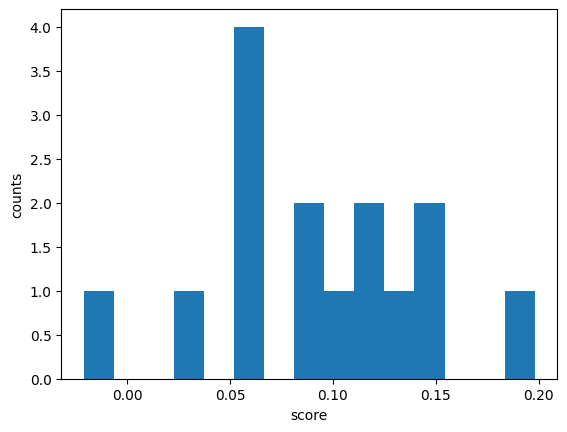

In [22]:
plt.hist(F1, bins=15)
plt.xlabel("score")
plt.ylabel("counts")
plt.show()

## Step 6: Fixing Metadata

In [28]:
!pip install nbformat --q

In [29]:
import nbformat
import os
from google.colab import drive, files

In [30]:
os.listdir("/content/drive/MyDrive/multimodal-xray-agent/notebooks")

['.gitkeep',
 '00_colab_setup.ipynb',
 '01_bootstrap.ipynb',
 '02_preprocessing.ipynb',
 '04_text_embedding_faiss_indexing.ipynb',
 '03_image_embedding_faiss_indexing.ipynb',
 '05_iu_xray_processing.ipynb',
 '06_generate_qa_pairs.ipynb',
 '08_finetune_biogpt_lora_run2.ipynb',
 '09_llama3_zero_shot_eval.ipynb',
 '07_finetune_biogpt_lora.ipynb',
 'Copy of 10_tokenization.ipynb',
 '12_llama3_finetuned_eval.ipynb',
 '11_finetune_llama3.2_lora.ipynb',
 '10_tokenization_fixed.ipynb',
 '10_tokenization.ipynb',
 '13_awq_quantization.ipynb',
 '14_quantized_llama_eval.ipynb',
 'vit-axavision-2-ChestX_eval.ipynb',
 '04_text_embedding_faiss_indexing_updated.ipynb',
 '15_crewai_setup.ipynb',
 '16_evaluation.ipynb']